In [1]:
#with RF Score ,results analysis
import os
import pandas as pd
import numpy as np

# 1. Load the raw data from the checkpoint file we streamed to disk
checkpoint_file = "hpc/02042026/docking_checkpoint.csv"

if not os.path.exists(checkpoint_file):
    raise RuntimeError("Checkpoint file not found. No docking was performed.")
    
raw_df = pd.read_csv(checkpoint_file)

# 2. Filter for successful results (Replacing your 'valid' list logic)
# We use pandas filtering instead of list comprehension
df_valid = raw_df[
    (raw_df["Status"] == "SUCCESS") & 
    (raw_df["Best_affinity_kcal_mol"].notna())
].copy()

if len(df_valid) < 2:
    raise RuntimeError("Not enough successful docking results for ROC analysis.")

# 3. Validation Counts
# Assuming 'Is_active' column exists (1 for active, 0 for decoy)
n_act_success = (df_valid["Is_active"] == 1).sum()
n_dec_success = (df_valid["Is_active"] == 0).sum()

print(f"  Valid results: {n_act_success} actives + {n_dec_success} decoys = {len(df_valid)} total")

if n_act_success == 0 or n_dec_success == 0:
    raise RuntimeError("Need at least 1 active AND 1 decoy with successful docking for ROC.")

# 4. Handle RF-Score edge cases
if 'RF_Score_pKd' in df_valid.columns:
    df_valid['RF_Score_pKd'] = pd.to_numeric(df_valid['RF_Score_pKd'], errors='coerce').fillna(0.0)
else:
    df_valid['RF_Score_pKd'] = 0.0

# 5. Calculate Ranks for Consensus Scoring
# rank_vina: Lower kcal/mol is better (1 is most negative)
df_valid['rank_vina'] = df_valid['Best_affinity_kcal_mol'].rank(method='min', ascending=True)

# rank_rf: Higher pKd is better (1 is highest value)
df_valid['rank_rf'] = df_valid['RF_Score_pKd'].rank(method='min', ascending=False)

# 6. Consensus Score: Rank Product (Lower is better)
# sqrt(rank1 * rank2) is a standard way to normalize rank products
df_valid['Consensus_Score'] = np.sqrt(df_valid['rank_vina'] * df_valid['rank_rf'])

# 7. Final Sort and Save
df_final = df_valid.sort_values("Consensus_Score", ascending=True)

  Valid results: 183 actives + 7407 decoys = 7590 total


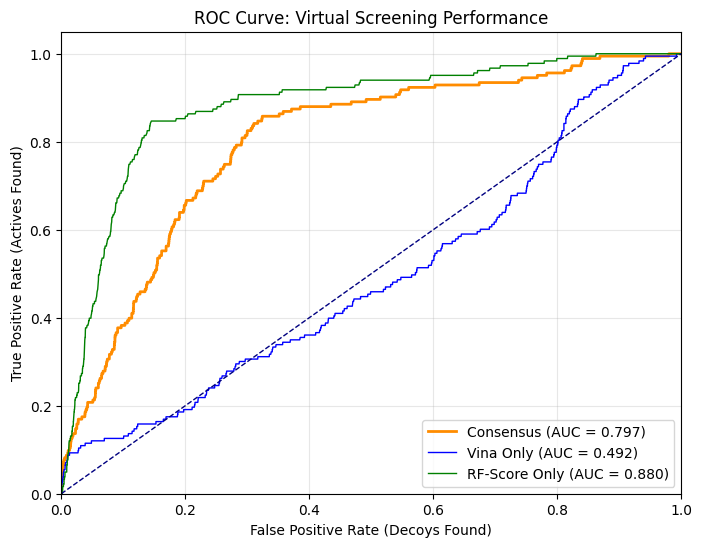

ROC AUC (Consensus): 0.7974


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Prepare Scores for ROC
# ROC functions expect higher values = better. 
# Since Consensus and Vina are "Lower is better", we negate them.
y_true = df_final['Is_active']
scores_consensus = -df_final['Consensus_Score']
scores_vina      = -df_final['Best_affinity_kcal_mol']
scores_rf        =  df_final['RF_Score_pKd'] # Already "Higher is better"

# 2. Calculate ROC Metrics
fpr_c, tpr_c, _ = roc_curve(y_true, scores_consensus)
roc_auc_c = auc(fpr_c, tpr_c)

fpr_v, tpr_v, _ = roc_curve(y_true, scores_vina)
roc_auc_v = auc(fpr_v, tpr_v)

fpr_rf, tpr_rf, _ = roc_curve(y_true, scores_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_c, tpr_c, color='darkorange', lw=2, label=f'Consensus (AUC = {roc_auc_c:.3f})')
plt.plot(fpr_v, tpr_v, color='blue',       lw=1, label=f'Vina Only (AUC = {roc_auc_v:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green',     lw=1, label=f'RF-Score Only (AUC = {roc_auc_rf:.3f})')

# Random Chance Line
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Decoys Found)')
plt.ylabel('True Positive Rate (Actives Found)')
plt.title('ROC Curve: Virtual Screening Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC (Consensus): {roc_auc_c:.4f}")

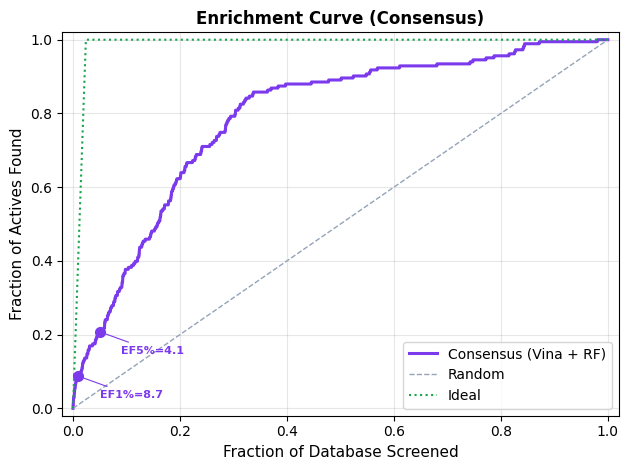

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

n_total = len(df_final)
sorted_lab = df_final["Is_active"].values  # Sorted by Consensus_Score (ascending)
n_pos = n_act_success

frac_screened = np.arange(0, n_total + 1) / n_total
frac_actives  = np.concatenate([[0], np.cumsum(sorted_lab) / n_pos])

# Plotting the Consensus curve - using a distinct color (purple) for the new method
plt.plot(frac_screened, frac_actives, color="#7c3aed", linewidth=2.2,
        label="Consensus (Vina + RF)")
plt.plot([0, 1], [0, 1], "--", color="#94a3b8", linewidth=1, label="Random")

# Ideal enrichment curve
ideal_x = [0, min(n_pos/n_total, 1.0), 1.0]
ideal_y = [0, 1.0, 1.0]
plt.plot(ideal_x, ideal_y, ":", color="#16a34a", linewidth=1.5, label="Ideal")

# Mark EF fractions on the curve (using the ef_results dict from previous step)
for frac, ef_data in ef_results.items():
    idx = ef_data["top_n"]
    x_pt = idx / n_total
    y_pt = ef_data["actives_found"] / n_pos
    plt.plot(x_pt, y_pt, "o", color="#7c3aed", markersize=7, zorder=5)
    plt.annotate(f"EF{frac:.0%}={ef_data['ef']:.1f}",
                xy=(x_pt, y_pt), xytext=(x_pt+0.04, y_pt-0.06),
                fontsize=8, fontweight="bold", color="#7c3aed",
                arrowprops=dict(arrowstyle="-", color="#7c3aed", lw=0.8))

plt.xlabel("Fraction of Database Screened", fontsize=11)
plt.ylabel("Fraction of Actives Found", fontsize=11)
plt.title("Enrichment Curve (Consensus)", fontsize=12, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.2))
plt.gca().yaxis.set_major_locator(MultipleLocator(0.2))
plt.grid(True, alpha=0.3)

# [Insert the Enrichment Curve code from the previous turn here onto ax2 = axes[1]]

plt.tight_layout()
plt.show()


In [24]:
alpha = 20.0
n = len(df_final)
# Get the 1-based ranks of the active compounds in the consensus-sorted list
ranks_of_actives = np.where(df_final["Is_active"].values == 1)[0] + 1

# Calculate the sum of exponential weights for observed actives
sum_exp = np.sum(np.exp(-alpha * (ranks_of_actives / n)))

ra = n_act_success / n
# Ideal: All actives ranked at the very top (ranks 1 to n_act_success)
ri_ideal = np.sum(np.exp(-alpha * (np.arange(1, n_act_success + 1) / n)))
# Random: Expected exponential sum for a random distribution
ri_rand = (ra * (1 - np.exp(-alpha))) / (np.exp(alpha / n) - 1)

bedroc = (sum_exp - ri_rand) / (ri_ideal - ri_rand) if (ri_ideal - ri_rand) != 0 else 0.0
print(f"\n  Consensus BEDROC (alpha=20) = {bedroc:.4f}")


  Consensus BEDROC (alpha=20) = 0.2070


In [20]:
# Print the ranks of the first 10 actives found
active_ranks = np.where(df_final["Is_active"].values == 1)[0] + 1
print(f"Ranks of the first 10 actives: {active_ranks[:10]}")
print(f"Total compounds in library: {len(df_final)}")


Ranks of the first 10 actives: [ 1  3  5  7  8 14 18 19 23 25]
Total compounds in library: 7590


In [5]:
print(f"\n  Consensus Enrichment Factors\n")
n_total = len(df_final)
_Ra = n_act_success / n_total   # Base ratio of actives in the total set
sorted_lab = df_final["Is_active"].values

ef_results = {}
print(f"  {'Fraction':>10}  {'Top-N':>6}  {'Actives found':>14}  {'EF':>8}  {'Max EF':>8}")
print(f"  {'-'*54}")

for frac in [0.01, 0.05]:
    # Determine how many compounds make up the top X%
    top_n = max(1, int(round(frac * n_total)))
    top_labels = sorted_lab[:top_n]
    n_act_in_top = int(top_labels.sum())
    
    hits_rate = n_act_in_top / top_n
    ef = hits_rate / _Ra if _Ra > 0 else 0.0
    
    # Max EF is capped by either finding all actives or the fraction size
    max_ef = (min(n_act_success, top_n) / top_n) / _Ra if _Ra > 0 else 0.0
    
    ef_results[frac] = {
        "top_n": top_n, 
        "actives_found": n_act_in_top,
        "ef": ef, 
        "max_ef": max_ef
    }
    print(f"  {frac:>10.1%}  {top_n:>6}  {n_act_in_top:>14}  {ef:>8.2f}  {max_ef:>8.2f}")


  Consensus Enrichment Factors

    Fraction   Top-N   Actives found        EF    Max EF
  ------------------------------------------------------
        1.0%      76              16      8.73     41.48
        5.0%     380              38      4.15     19.97


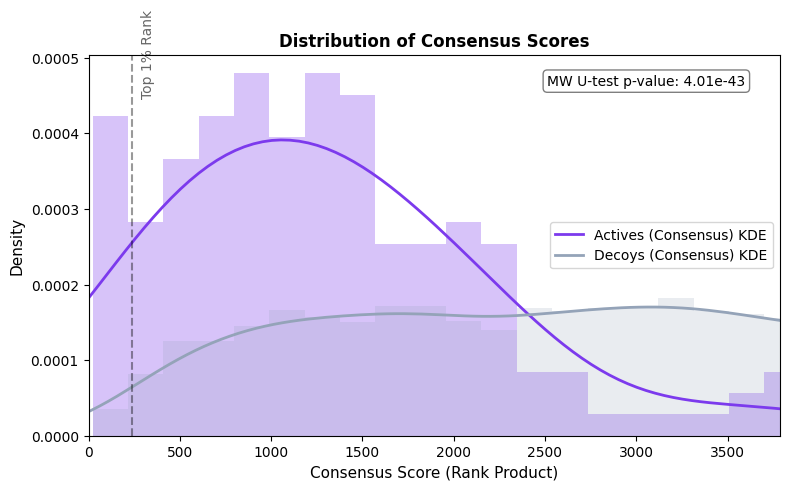

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

# 1. Prepare Data from the Consensus DataFrame
# We use the 'Consensus_Score' column (Rank Product: lower is better)
act_scores = df_final[df_final["Is_active"] == 1]["Consensus_Score"].dropna()
dec_scores = df_final[df_final["Is_active"] == 0]["Consensus_Score"].dropna()

fig, ax3 = plt.subplots(figsize=(8, 5))

# 2. Dynamic Binning for Consensus Ranks
# Consensus scores are rank-based, so we define bins from 1 to the max rank found
all_scores = pd.concat([act_scores, dec_scores])
bins = np.linspace(all_scores.min(), all_scores.max(), 40)

# 3. Plot Histograms and KDEs
# Using purple (#7c3aed) for Consensus Actives to match your previous panels
sns.kdeplot(act_scores, ax=ax3, color="#7c3aed", linewidth=2, label="Actives (Consensus) KDE")
sns.kdeplot(dec_scores, ax=ax3, color="#94a3b8", linewidth=2, label="Decoys (Consensus) KDE")

ax3.hist(act_scores, bins=bins, density=True, alpha=0.3, color="#7c3aed", edgecolor="none")
ax3.hist(dec_scores, bins=bins, density=True, alpha=0.2, color="#94a3b8", edgecolor="none")

# 4. Refine Axes for Rank Distribution
# We focus on the "Top" (low rank values) where actives should cluster
ax3.set_xlim(0, all_scores.max() * 0.5) # Zoom into the top 50% for clarity
ax3.set_xlabel("Consensus Score (Rank Product)", fontsize=11)
ax3.set_ylabel("Density", fontsize=11)
ax3.set_title("Distribution of Consensus Scores", fontsize=12, fontweight="bold")
ax3.legend()


# 1. Calculate Mann-Whitney U test
stat, p_val = mannwhitneyu(act_scores, dec_scores, alternative='two-sided')

# 2. Add the result as a text box on your plot
ax3.text(0.95, 0.95, f"MW U-test p-value: {p_val:.2e}", 
         transform=ax3.transAxes, ha='right', va='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
         fontsize=10)

# 3. Optional: Add a vertical line for the "Top 1%" threshold
top_1_threshold = df_final.iloc[int(0.01 * len(df_final))]["Consensus_Score"]
ax3.axvline(top_1_threshold, color='black', linestyle='--', alpha=0.4)
ax3.text(top_1_threshold + 50, 0.00045, "Top 1% Rank", rotation=90, alpha=0.6)

# 5. Clean up and Save
plt.tight_layout()
plt.show()